Sklearn k=1 | Acurácia: 0.9667 | Precisão: 0.9704 | Revocação: 0.9667


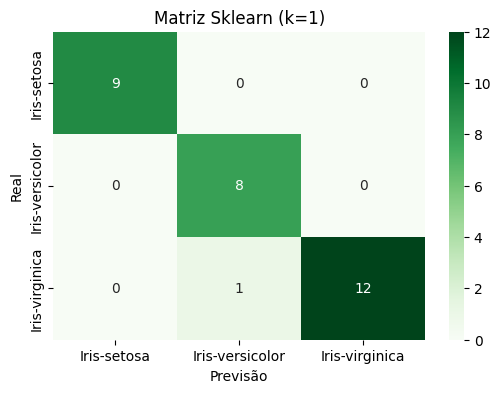

Sklearn k=3 | Acurácia: 0.9667 | Precisão: 0.9704 | Revocação: 0.9667


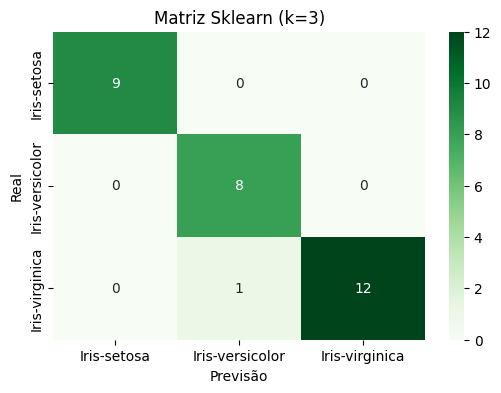

Sklearn k=5 | Acurácia: 0.9667 | Precisão: 0.9704 | Revocação: 0.9667


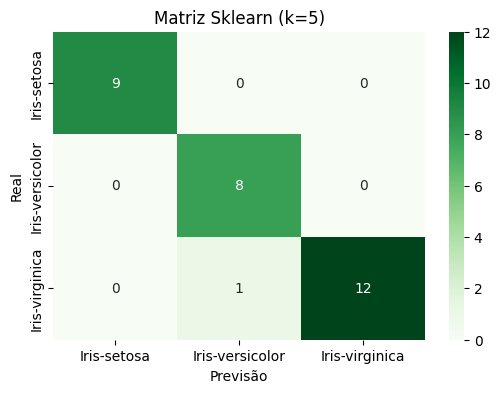

Sklearn k=7 | Acurácia: 0.9333 | Precisão: 0.9467 | Revocação: 0.9333


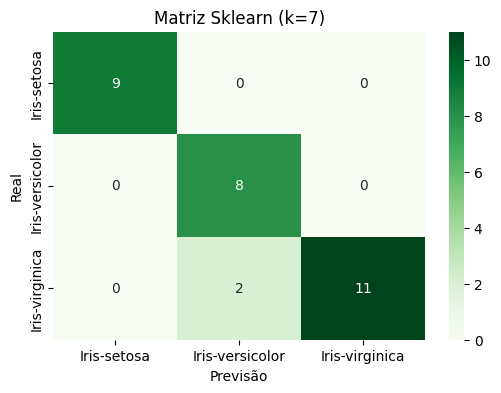

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
colunas = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
df = pd.read_csv(url, names=colunas)

df_embaralhado = df.sample(frac=1, random_state=73).reset_index(drop=True)

tamanho_treino = int(0.8 * len(df_embaralhado))

df_treino = df_embaralhado.iloc[:tamanho_treino]
df_teste = df_embaralhado.iloc[tamanho_treino:]

X_treino = df_treino.drop('species', axis=1).values
y_treino = df_treino['species'].values

X_teste = df_teste.drop('species', axis=1).values
y_teste = df_teste['species'].values

classes = np.unique(y_teste)
valores_k = [1, 3, 5, 7]

for k in valores_k:
    modelo_sklearn = KNeighborsClassifier(n_neighbors=k)
    modelo_sklearn.fit(X_treino, y_treino)
    previsoes_sklearn = modelo_sklearn.predict(X_teste)
    
    acuracia = accuracy_score(y_teste, previsoes_sklearn)
    precisao = precision_score(y_teste, previsoes_sklearn, average='weighted')
    revocacao = recall_score(y_teste, previsoes_sklearn, average='weighted')
    
    print(f"Sklearn k={k} | Acurácia: {acuracia:.4f} | Precisão: {precisao:.4f} | Revocação: {revocacao:.4f}")
    
    matriz_sklearn = confusion_matrix(y_teste, previsoes_sklearn)
    
    plt.figure(figsize=(6, 4))
    sns.heatmap(matriz_sklearn, annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes)
    plt.title(f'Matriz Sklearn (k={k})')
    plt.xlabel('Previsão')
    plt.ylabel('Real')
    plt.show()